In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'

from astropy.io import fits
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.visualization import simple_norm
from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Const2D, Gaussian2D
from astropy.stats import sigma_clipped_stats, SigmaClip, mad_std
import astropy.coordinates as coord
from astropy.wcs import WCS
from astropy.wcs import utils
from astropy.time import Time

from photutils.aperture import ApertureStats, CircularAperture, CircularAnnulus, RectangularAperture, aperture_photometry
from photutils.background import MMMBackground,SExtractorBackground,Background2D
from photutils.utils import calc_total_error
from astropy.coordinates import SkyCoord

from datetime import datetime
from astropy.coordinates import EarthLocation, AltAz, get_body

from matplotlib.lines import Line2D

from collections import defaultdict
from astropy.stats import sigma_clip
from pathlib import Path

c:\Users\lunal\miniconda3\envs\astro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
directory = Path(r"...") 

In [ ]:
from pathlib import Path
from astropy.io import fits
import pandas as pd

directory = Path(r"...")

for fname in sorted(directory.glob("FORS2*.fits")):

    with fits.open(fname) as hdul:

        object_name = hdul[0].header.get("OBJECT")
        catg = hdul[0].header.get("HIERARCH ESO DPR CATG")

        if object_name is not None and catg == "SCIENCE":

            print(fname.name)
            print("OBJECT:", object_name)

            for i, hdu in enumerate(hdul):
                print(i, hdu.header.get("EXTNAME"))

            break

FORS2.2021-01-26T00_37_12.874.fits
OBJECT: F60
0 CHIP1


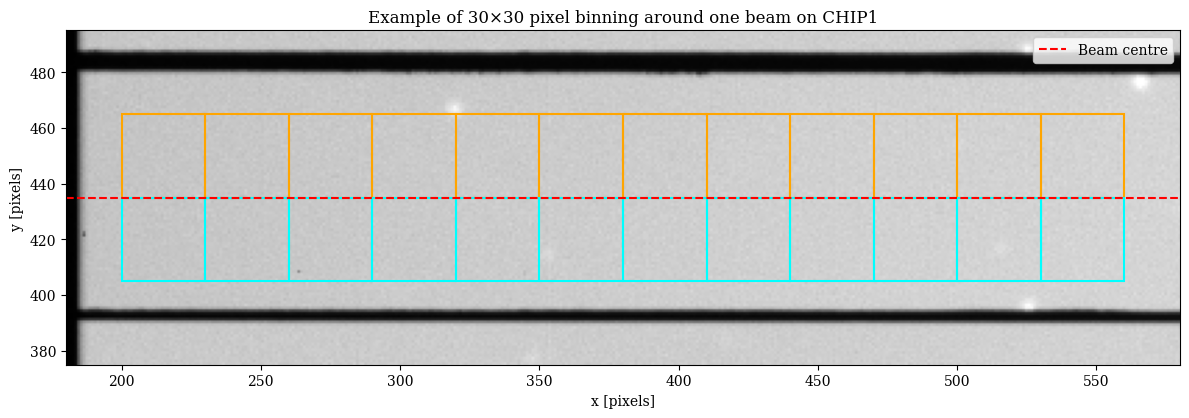

In [ ]:
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

fname = directory / "FORS2.2021-01-26T01_03_29.541.fits"

chip = "CHIP1"          
y0 = 435               
bin_size = 30
x_left = 200
n_bins_x_show = 12     

with fits.open(fname) as hdul:
    image = hdul[chip].data.astype(float)


x1 = x_left - 20
x2 = x_left + n_bins_x_show * bin_size + 20
y1 = y0 - 60
y2 = y0 + 60

cutout = image[y1:y2, x1:x2]

z = ZScaleInterval()
vmin, vmax = z.get_limits(cutout)

fig, ax = plt.subplots(figsize=(12, 4))

ax.imshow(
    cutout,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
    extent=[x1, x2, y1, y2]
)


ax.axhline(y0, color="red", linestyle="--", linewidth=1.5, label="Beam centre")

for i in range(n_bins_x_show):
    bx = x_left + i * bin_size

    rect_upper = Rectangle(
        (bx, y0),
        bin_size,
        bin_size,
        fill=False,
        edgecolor="orange",
        linewidth=1.5
    )

    rect_lower = Rectangle(
        (bx, y0 - bin_size),
        bin_size,
        bin_size,
        fill=False,
        edgecolor="cyan",
        linewidth=1.5
    )

    ax.add_patch(rect_upper)
    ax.add_patch(rect_lower)

ax.set_title(f"Example of 30×30 pixel binning around one beam on {chip}")
ax.set_xlabel("x [pixels]")
ax.set_ylabel("y [pixels]")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [5]:
B_mid_1 = np.array([72, 167, 253, 348, 435, 531, 615, 712, 796, 894])
B_mid_2 = np.array([389, 478, 571, 664, 753, 846])
V_mid_1 = np.array([73, 165, 254, 347, 436, 529, 616, 710, 797, 892])
V_mid_2 = np.array([390, 478, 571, 662, 754, 845])
R_mid_1 = np.array([73, 164, 254, 346, 436, 528, 616, 709, 797, 891])
R_mid_2 = np.array([390, 477, 571, 661, 754, 844])
I_mid_1 = np.array([74, 164, 255, 345, 437, 528, 617, 709, 798, 891])
I_mid_2 = np.array([391, 477, 572, 661, 755, 844])

CHIP1 file: FORS2.2021-01-26T01_03_29.541.fits
CHIP1 shape: (1034, 2048)
CHIP1 EXTNAME: CHIP1
CHIP2 file: FORS2.2021-01-26T01_03_29.542.fits
CHIP2 shape: (1034, 2048)
CHIP2 EXTNAME: CHIP2


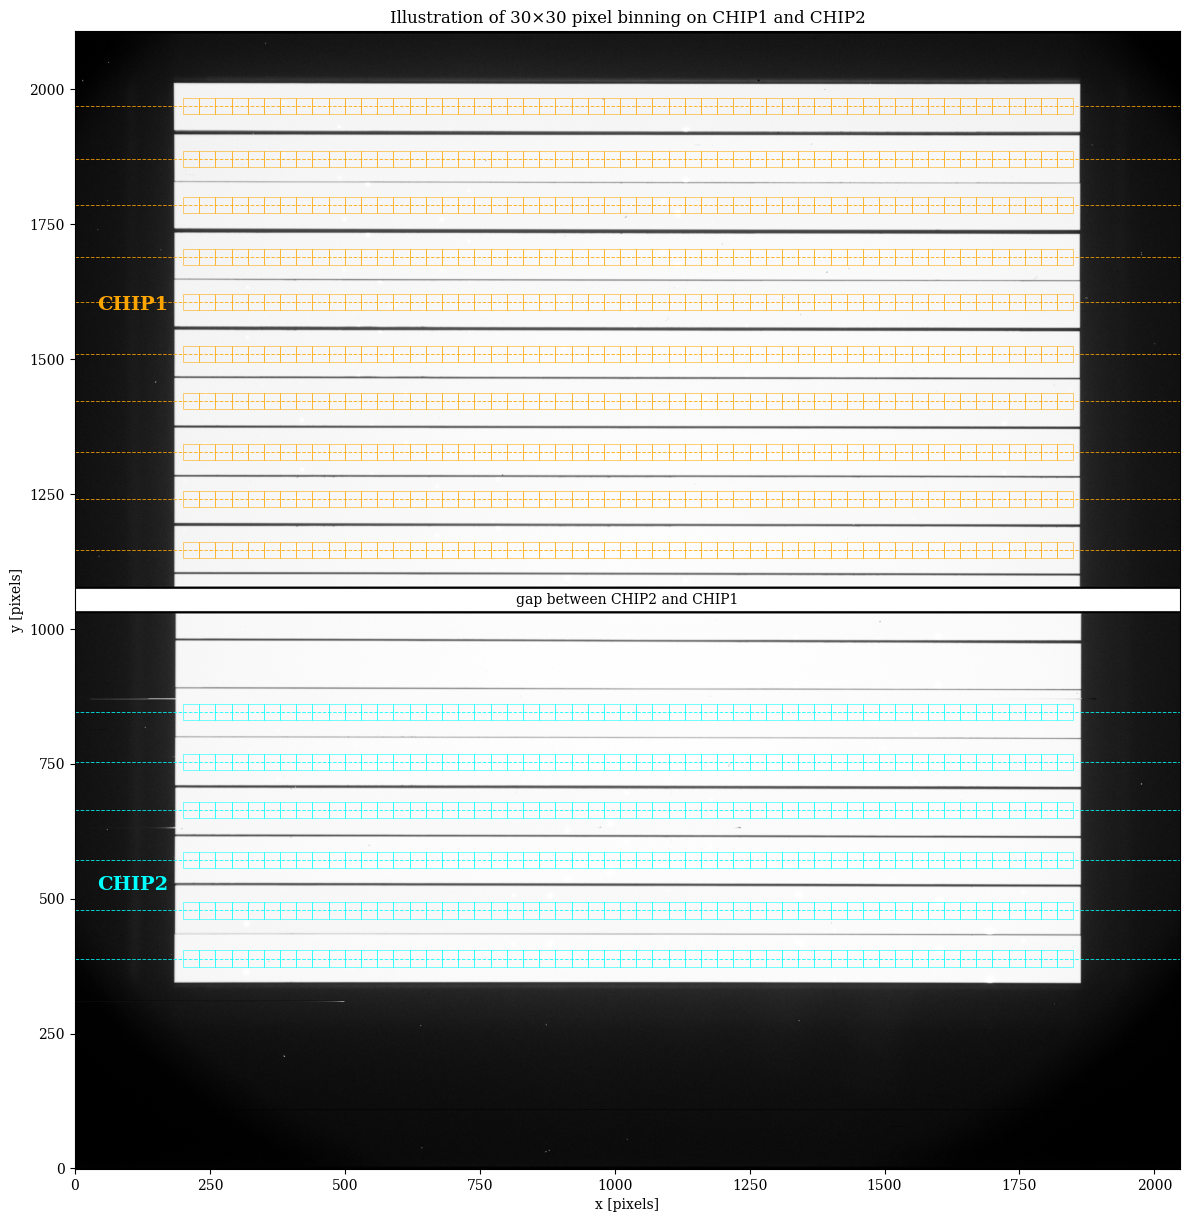

In [ ]:
from pathlib import Path
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

directory = Path(r"...")

fname_chip1 = directory / "FORS2.2021-01-26T01_03_29.541.fits"
fname_chip2 = directory / "FORS2.2021-01-26T01_03_29.542.fits"

y_mid_chip1 = B_mid_1
y_mid_chip2 = B_mid_2

bin_size = 30
x_left = 200
n_bins_x = 55

def read_single_chip(fname):
    with fits.open(fname) as hdul:
       
        if hdul[0].data is not None:
            data = hdul[0].data.astype(float)
            header = hdul[0].header
        else:
            data = hdul[1].data.astype(float)
            header = hdul[1].header

    return data, header

chip1, hdr1 = read_single_chip(fname_chip1)
chip2, hdr2 = read_single_chip(fname_chip2)

print("CHIP1 file:", fname_chip1.name)
print("CHIP1 shape:", chip1.shape)
print("CHIP1 EXTNAME:", hdr1.get("EXTNAME"))

print("CHIP2 file:", fname_chip2.name)
print("CHIP2 shape:", chip2.shape)
print("CHIP2 EXTNAME:", hdr2.get("EXTNAME"))

gap = 40

ny2, nx2 = chip2.shape
ny1, nx1 = chip1.shape

nx = max(nx1, nx2)

combined = np.full((ny2 + gap + ny1, nx), np.nan)

combined[0:ny2, 0:nx2] = chip2
combined[ny2 + gap:ny2 + gap + ny1, 0:nx1] = chip1

chip2_y_offset = 0
chip1_y_offset = ny2 + gap

from astropy.visualization import ImageNormalize, AsinhStretch

valid = combined[np.isfinite(combined)]

vmin, vmax = np.nanpercentile(valid, [1, 99.5])

norm = ImageNormalize(
    vmin=vmin,
    vmax=vmax,
    stretch=AsinhStretch(a=0.03)
)

fig, ax = plt.subplots(figsize=(12, 14))

ax.imshow(
    combined,
    origin="lower",
    cmap="gray",
    norm=norm
)

def draw_bins(y_mids, y_offset, color):
    for y0 in y_mids:
        y0_global = y0 + y_offset

        ax.axhline(
            y0_global,
            color=color,
            linestyle="--",
            linewidth=0.7,
            alpha=0.8
        )

        for i in range(n_bins_x):
            bx = x_left + i * bin_size

            rect = Rectangle(
                (bx, y0_global - bin_size / 2),
                bin_size,
                bin_size,
                fill=False,
                edgecolor=color,
                linewidth=0.45,
                alpha=0.85
            )

            ax.add_patch(rect)

draw_bins(y_mid_chip2, chip2_y_offset, "cyan")
draw_bins(y_mid_chip1, chip1_y_offset, "orange")
ax.axhspan(ny2, ny2 + gap, color="white", alpha=0.85)

ax.text(
    nx / 2,
    ny2 + gap / 2,
    "gap between CHIP2 and CHIP1",
    ha="center",
    va="center",
    fontsize=10
)

ax.text(
    40,
    ny2 / 2,
    "CHIP2",
    color="cyan",
    fontsize=14,
    weight="bold"
)

ax.text(
    40,
    chip1_y_offset + ny1 / 2,
    "CHIP1",
    color="orange",
    fontsize=14,
    weight="bold"
)

ax.set_title("Illustration of 30×30 pixel binning on CHIP1 and CHIP2")
ax.set_xlabel("x [pixels]")
ax.set_ylabel("y [pixels]")

plt.tight_layout()
plt.show()

File 1: FORS2.2021-01-26T01_03_29.541.fits
Shape: (1034, 2048)
EXTNAME: CHIP1

File 2: FORS2.2021-01-26T01_03_29.542.fits
Shape: (1034, 2048)
EXTNAME: CHIP2


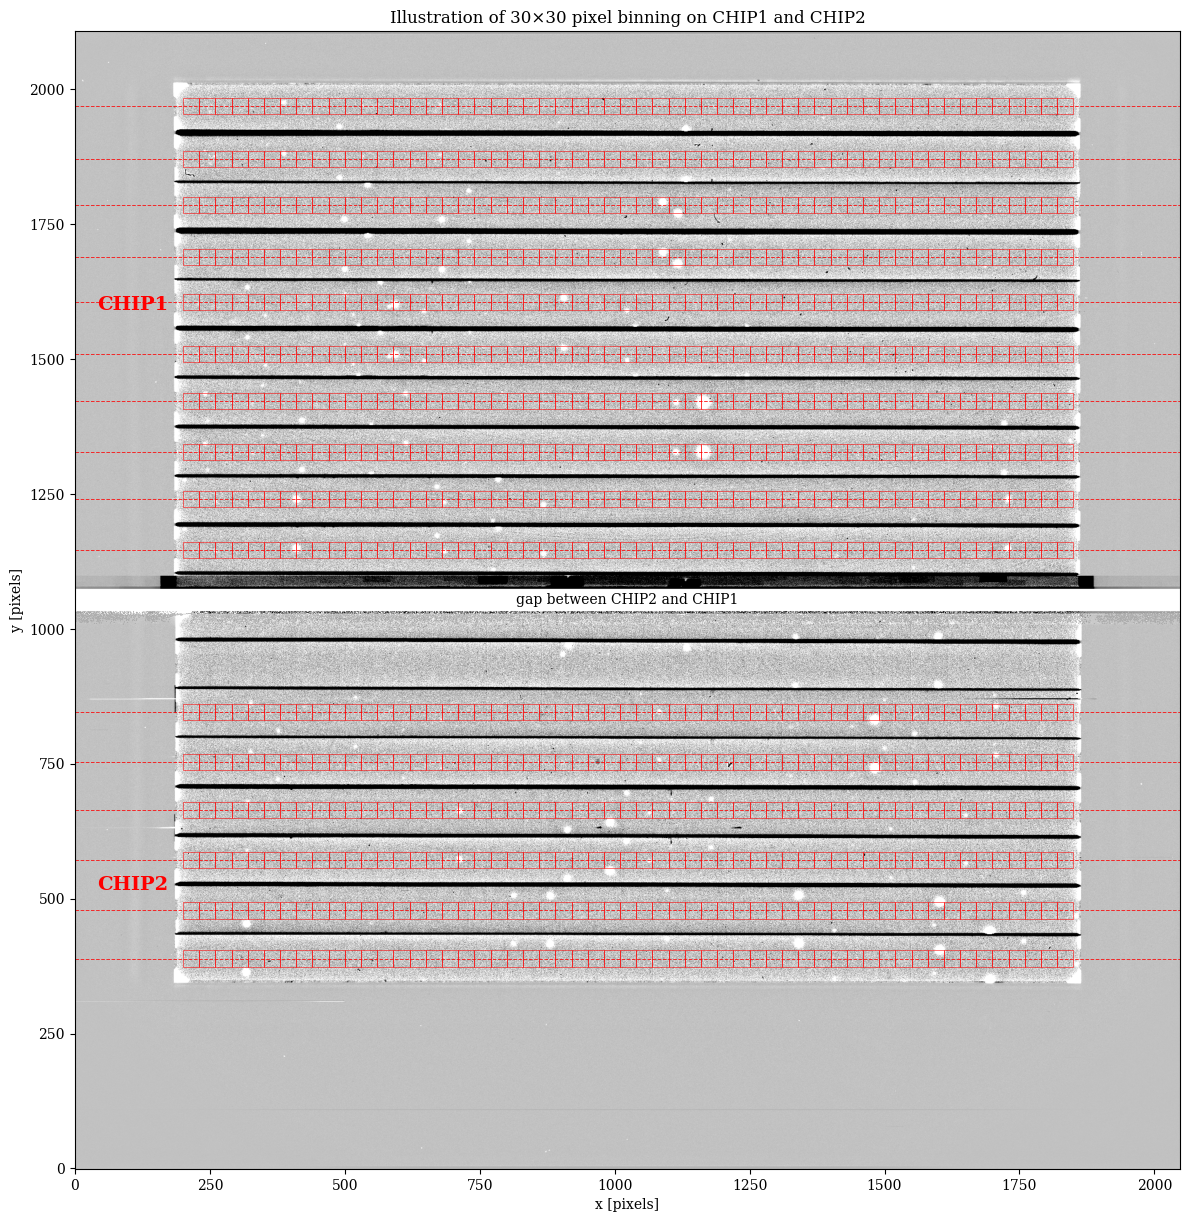

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import ImageNormalize, LinearStretch
from matplotlib.patches import Rectangle
from scipy.ndimage import median_filter

y_mid_chip1 = B_mid_1
y_mid_chip2 = B_mid_2

bin_size = 30
x_left = 200
n_bins_x = 55

def read_single_chip(fname):
    with fits.open(fname) as hdul:
        if hdul[0].data is not None:
            data = hdul[0].data.astype(float)
            header = hdul[0].header
        else:
            data = hdul[1].data.astype(float)
            header = hdul[1].header

    return data, header


chip1, hdr1 = read_single_chip(fname_chip1)
chip2, hdr2 = read_single_chip(fname_chip2)

print("File 1:", fname_chip1.name)
print("Shape:", chip1.shape)
print("EXTNAME:", hdr1.get("EXTNAME"))
print()

print("File 2:", fname_chip2.name)
print("Shape:", chip2.shape)
print("EXTNAME:", hdr2.get("EXTNAME"))

gap = 40

ny2, nx2 = chip2.shape
ny1, nx1 = chip1.shape

nx = max(nx1, nx2)

combined = np.full((ny2 + gap + ny1, nx), np.nan)

combined[0:ny2, 0:nx2] = chip2
combined[ny2 + gap:ny2 + gap + ny1, 0:nx1] = chip1

chip2_y_offset = 0
chip1_y_offset = ny2 + gap

display_img = combined.copy()

smooth = median_filter(display_img, size=(51, 51))

contrast_img = display_img - smooth

valid = contrast_img[np.isfinite(contrast_img)]

vmin, vmax = np.nanpercentile(valid, [5, 95])

norm = ImageNormalize(
    vmin=vmin,
    vmax=vmax,
    stretch=LinearStretch()
)

fig, ax = plt.subplots(figsize=(12, 14))

ax.imshow(
    contrast_img,
    origin="lower",
    cmap="gray",
    norm=norm
)

def draw_bins(y_mids, y_offset, color):
    for y0 in y_mids:
        y0_global = y0 + y_offset

        
        ax.axhline(
            y0_global,
            color=color,
            linestyle="--",
            linewidth=0.7,
            alpha=0.8
        )

      
        for i in range(n_bins_x):
            bx = x_left + i * bin_size

            rect = Rectangle(
                (bx, y0_global - bin_size / 2),
                bin_size,
                bin_size,
                fill=False,
                edgecolor=color,
                linewidth=0.45,
                alpha=0.85
            )

            ax.add_patch(rect)

draw_bins(y_mid_chip2, chip2_y_offset, "red")
draw_bins(y_mid_chip1, chip1_y_offset, "red")

ax.axhspan(ny2, ny2 + gap, color="white", alpha=0.9)

ax.text(
    nx / 2,
    ny2 + gap / 2,
    "gap between CHIP2 and CHIP1",
    ha="center",
    va="center",
    fontsize=10,
    color="black"
)

ax.text(
    40,
    ny2 / 2,
    "CHIP2",
    color="red",
    fontsize=14,
    weight="bold"
)

ax.text(
    40,
    chip1_y_offset + ny1 / 2,
    "CHIP1",
    color="red",
    fontsize=14,
    weight="bold"
)

ax.set_title("Illustration of 30×30 pixel binning on CHIP1 and CHIP2")
ax.set_xlabel("x [pixels]")
ax.set_ylabel("y [pixels]")

plt.tight_layout()
plt.show()